# 알고리즘 기말 프로젝트 — Score Function Design

- **제출일**: `<YYYY.MM.DD HH:MM>`
- **파일명**: `이름_학번_화학제품군.ipynb`  (예: 신현길_12312312_pesticide.ipynb)

## 학번 / 이름

- **학번**: ` 20251259 `
- **이름**: ` 신혜지  `
- **score에 대한 간략한 설명**: `fragrance`-likeness를 계산하는 score (cosmetic / food additive / fragrance / ... )

## 채점 기준 (100점)

| 영역 | 배점 | 만점 기준 |
|---|---|---|
| **(1) Negative 데이터 준비** | 20 | "구조 유사도"를 통해 negative 집합을 찾아낸 기준? (유사도 측정 방법 & Structural similarity 기준 설정) |
| **(2) Score 함수 설계** | 20 | **(a) 분자 속성 범위 (전체 데이터에서 property 범위 계산 방식)** + **(b) alert 구조 패턴(scaffold 및 부분 구조의 smarts 패턴)** 두 요소 모두 포함. score에 대한 설명은 markdown에 기재. |
| **(3) Score 평가 — goodness** | 20 | positive vs negative 점수 분포 비교 (히스토그램/ROC/AUC 등 score 성능의 근거가 되는 시각화 자료 제시) |
| **(4) 설명** | 10 | 각 알고리즘을 mermaid를 이용해서 표현하고 설명글 추가 (markdown 및 주석으로 표기) |


### 가산점 (선택)

| 가산 | 점수 | 조건 |
|---|---|---|
| **(A) 다른 화학 제품군 score** | +10 | pesticide 외 1종 이상(cosmetic / food additive / fragrance / surfactant / dye 등)의 PubChem classification 데이터로 별도 score 함수 설계 + 평가 |
| **(B) Score 기반 구조 생성** | +10 | 본인 score 를 reward 로 사용해 score가 개선된 새로운 구조 생성. |
| **(C) 계산 자원과 계산 시간** | +10 | mpi를 이용해서 대량의 자원으로 계산 시간을 대폭 줄이거나, local 환경에서 합리적으로 계산이 진행될 수 있도록 문제를 효율적으로 압축시킨 방법 적용 (mpi script와 계산 결과에 대한 log 필요) |

### 제출 결과물 (결과를 재현하기 위해 필요한 파일들)
1. ipynb (mpi를 사용했다면, mpi4py script)
2. data files (pesticide, cosmetics, food additives, drug, ..., format: csv)
3. negative list file (format: csv)
4. score 평가 시각화 자료 (mpi에서 실행해서 얻은 plot은 notebook markdown에 삽입)

---
# Task 1. Negative 데이터 준비 (25점)

**문제**: 양성(positive) 분자와 "구조적으로 다른" 분자 집합을 어떻게 만들 것인가?

Score 함수의 평가는 **양성과 음성을 얼마나 잘 구분하는가** 로 측정합니다. 그러려면 먼저 음성 집합을 정의해야 합니다.

**📝 본인 선택과 이유 (직접 작성):**

- 선택한 기준: ___
- 이유: ___

In [2]:
# 셀은 필요한 만큼 추가. (mpi로 만들어낸 결과는 markdown에 추가. python script는 별도 제출.)

In [20]:
import pandas as pd 

fragrance_df = pd.read_csv("fragrance.csv")
drug_df = pd.read_csv("drug.csv")

print("Fragrance: ", fragrance_df.shape)
print("Drug:", drug_df.shape)

Fragrance:  (2531, 38)
Drug: (3098, 38)


이름: Compound_CID / Name / SMILES

In [21]:
from rdkit import Chem 
smiles = df["SMILES"]
mols = [Chem.MolFromSmiles(s) for s in smiles]

valid = []

for s in smiles:
    mol = Chem.MolFromSmiles(s)
    if mol is not None:      # Rdkit에서 처리할 수 없는 잘못된 구조 제거 -> 계산 오류 방지 
        valid.append(s)
print(len(valid))     

2531


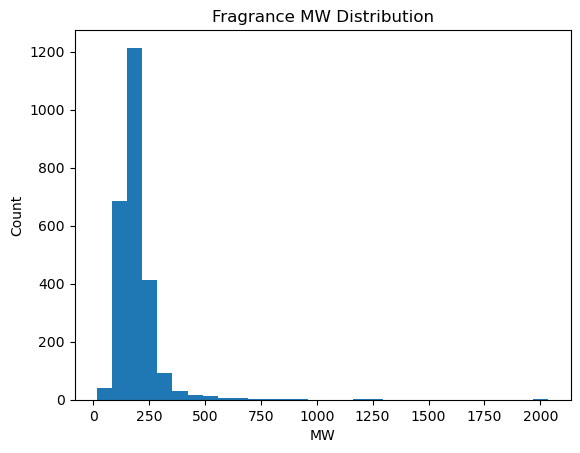

In [ ]:
##### 삭제 ##### 아래의 markdown내용은 어떻게 할 지 고민해볼 것. 
#1. 이동 후 markdown 내용 보충 
#2. markdown 걍 삭제 


import matplotlib.pyplot as plt 

plt.hist(desc_df["MW"], bins = 30)
plt.xlabel("MW")
plt.ylabel("Count")
plt.title("Fragrance MW Distribution")
plt.show()

# fragrance 분자들의 descriptor 분포 시각화 -> score 함수 설계에 사용할 기준 범위를 탐색

위의 히스토그램? 
fragrance 분자들의 분자량(MW)이 어디에 많이 분포하는지 보기 위함 = <향료다운 분자량의 범위는?>을 알아보려고

대부분의 fragrance 분자들이 약 100-300MW 사이에 몰려있음 (특히 150-250 쯤)

1000 부근, 1250, 2000 까지 가 있는 값은 매우 큰 분자이거나 polymer 성 구조 혹은 이상 데이터 일 가능성 있음. 

정리하면 

fragrance dataset 의 MW 분포를 히스토그램 생성을 통해 분석한 결과, 대부분의 분자가 100-300 범위에 분포하였으며 특히 150-250 구간에 가장 높은 빈도가 나타났다. 이를 통해 fragrance-like molecule은 지나치게 크지는 않은 중소형 분자 특성을 가진다고 판단하였으며 이 범위를 property-based score 설계에 반영하였다. 

In [9]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import pandas as pd

# valid smiles -> mol 변환
mols = [Chem.MolFromSmiles(s) for s in valid]

# descriptor 계산
desc_df = pd.DataFrame({
    "MW": [Descriptors.MolWt(m) for m in mols],
    "logP": [Descriptors.MolLogP(m) for m in mols],
    "TPSA": [rdMolDescriptors.CalcTPSA(m) for m in mols],
    "HBA": [rdMolDescriptors.CalcNumHBA(m) for m in mols],
    "HBD": [rdMolDescriptors.CalcNumHBD(m) for m in mols],
    "RotBonds": [rdMolDescriptors.CalcNumRotatableBonds(m) for m in mols]
})

desc_df.head()

,MW,logP,TPSA,HBA,HBD,RotBonds
0,150.177,1.7038,37.30,1,1,3
1,122.123,1.2047,37.30,2,1,1
2,60.052,0.0909,37.30,1,1,0
3,44.053,0.2052,17.07,1,0,0
4,88.106,-0.0438,37.30,2,1,1


In [25]:
#  Drug 유효 분자 추출 

from rdkit import Chem 

drug_valid = []

for s in drug_df["smiles"].dropna():
    mol = Chem.MolFromSmiles(s)

    if mol is not None:
        drug_valid.append(s)

print(len(drug_valid))

3098


[14:00:27] WARNING: not removing hydrogen atom without neighbors
[14:00:27] WARNING: not removing hydrogen atom without neighbors
[14:00:27] WARNING: not removing hydrogen atom without neighbors
[14:00:27] WARNING: not removing hydrogen atom without neighbors


In [26]:
# Drug Descriptor 계산 

from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import pandas as pd

drug_mols = [Chem.MolFromSmiles(s) for s in drug_valid]

drug_desc = pd.DataFrame({
    "MW": [Descriptors.MolWt(m) for m in drug_mols],
    "logP": [Descriptors.MolLogP(m) for m in drug_mols],
    "TPSA": [rdMolDescriptors.CalcTPSA(m) for m in drug_mols],
    "HBA": [rdMolDescriptors.CalcNumHBA(m) for m in drug_mols],
    "HBD": [rdMolDescriptors.CalcNumHBD(m) for m in drug_mols],
    "RotBonds": [rdMolDescriptors.CalcNumRotatableBonds(m) for m in drug_mols]
})

drug_desc.head()

[14:01:30] WARNING: not removing hydrogen atom without neighbors
[14:01:30] WARNING: not removing hydrogen atom without neighbors
[14:01:30] WARNING: not removing hydrogen atom without neighbors
[14:01:30] WARNING: not removing hydrogen atom without neighbors


,MW,logP,TPSA,HBA,HBD,RotBonds
0,98.960,1.4640,0.00,0,0,1
1,120.060,-1.4835,94.83,3,3,2
2,122.123,1.2047,37.30,2,1,1
3,138.122,1.0904,57.53,2,2,1
4,60.052,0.0909,37.30,1,1,0


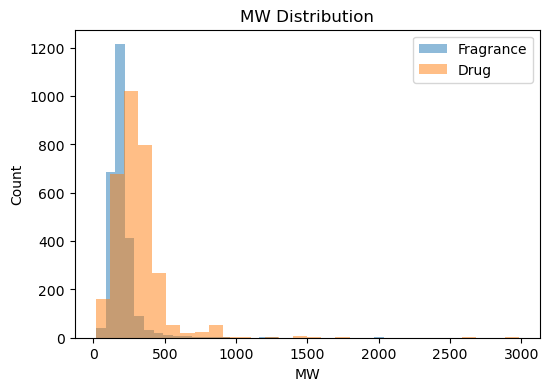

In [27]:
# MW 비교 - Drug 

import matplotlib.pyplot as plt 

plt.figure(figsize=(6,4))

plt.hist(desc_df["MW"], 
        bins=30, 
        alpha = 0.5, 
        label="Fragrance")

plt.hist(drug_desc["MW"], 
        bins = 30, 
        alpha = 0.5, 
        label = "Drug")

plt.xlabel("MW")
plt.ylabel("Count")
plt.title("MW Distribution")

plt.legend()

plt.show()

양성과 음성이 구조적으로 다른가? 물성(Descriptor 차이)

Fragrance는 약 100~300 구간에 집중적으로 분포 
Drug는 약 100~500에 비교적 더 넓게 분포하며 1000 이상, 3000 근처까지도 일부 존재함. 
Fragrance는 그에 반해 고분자 영역이 훨씬 적음. 

Fragrance 분자는 상대적으로 낮은 분자량 영역에 집중되어 있었고 Drug 분자는 더 넓은 분자량 분포를 보였다. 


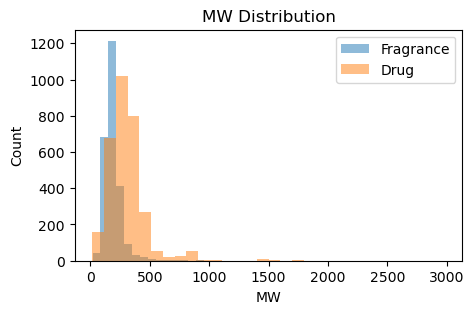

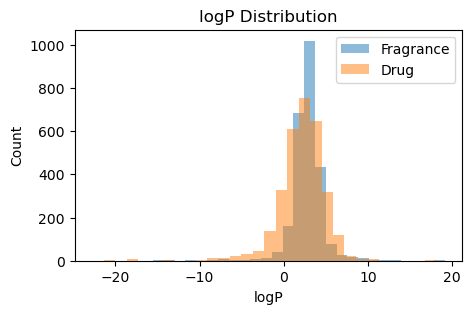

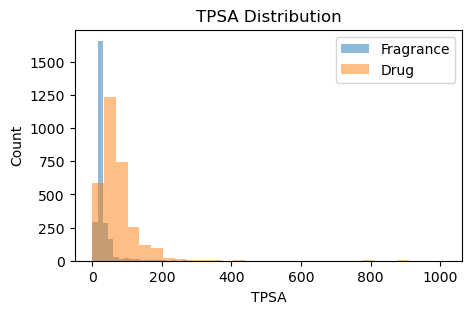

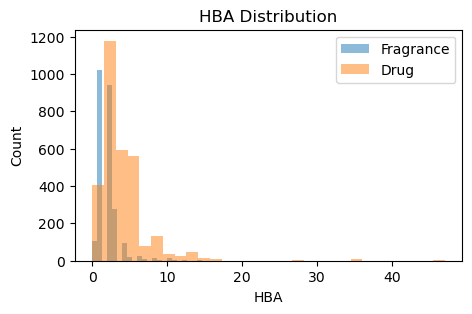

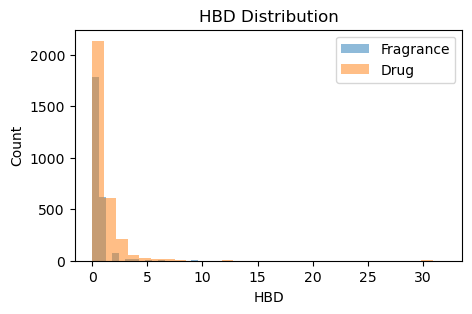

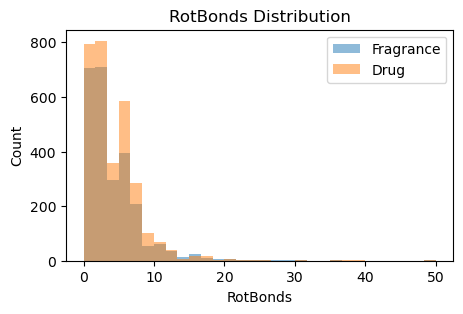

In [28]:
# logP, TPSA, HBA, HBD, RotBonds 도 비교 

import matplotlib.pyplot as plt 

cols = ["MW", "logP", "TPSA", "HBA", "HBD", "RotBonds"]

for col in cols: 
    plt.figure(figsize=(5, 3))

    plt.hist(desc_df[col], 
            bins = 30, 
            alpha = 0.5, 
            label = "Fragrance")

    plt.hist(drug_desc[col], 
            bins = 30, 
            alpha = 0.5, 
            label = "Drug")

    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"{col} Distribution")
    
    plt.legend()

    plt.show()

결: Drug, Fragrance 그래프가 거의 겹치므로 Descriptor 하나만 가지고는 둘을 깔끔하게 분리하기 어렵다. 


In [ ]:
import matplotlib.pyplot as plt

plt.hist(desc_df["MW"], bins=30)

plt.xlabel("MW")
plt.ylabel("Count")
plt.title("Fragrance MW Distribution")

plt.show()

위의 코드는 각 분자의 분자량, 소수성, 극성 표면적, 수소결합 acceptor, 수소결합 donor, 회전 가능한 결합 수를 알아보고자 함. 

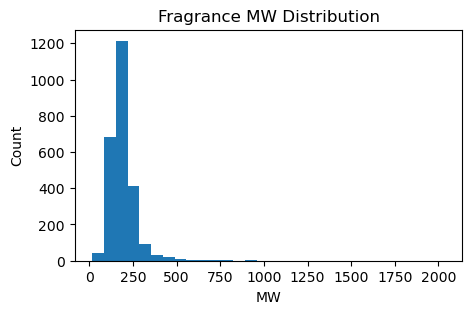

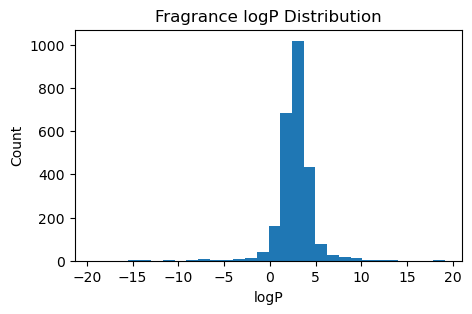

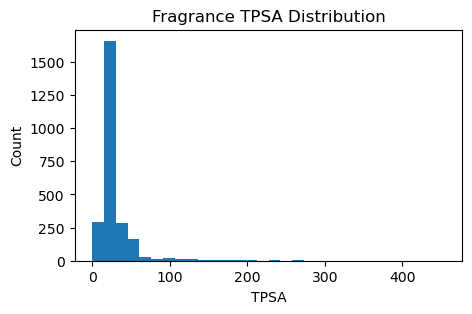

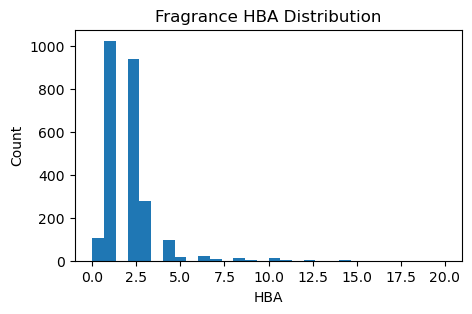

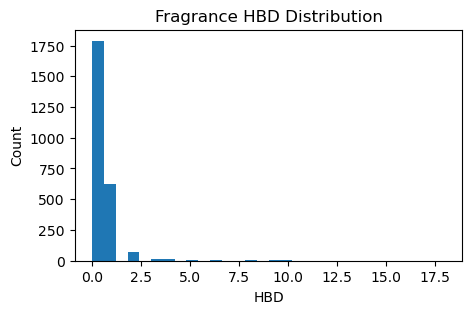

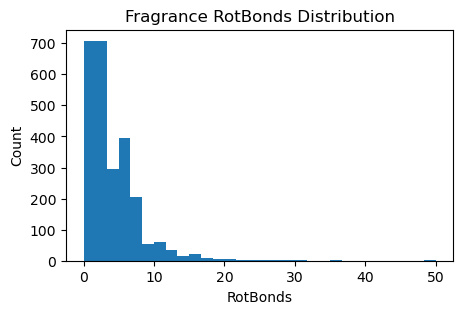

In [10]:
import matplotlib.pyplot as plt

for col in desc_df.columns:

    plt.figure(figsize=(5,3))

    plt.hist(desc_df[col], bins=30)

    plt.title(f"Fragrance {col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

위의 히스토그램을 보았을 때 대부분 100-300 범위에 집중되어 있는 것을 알 수 있음 

그래서 score 후보를 정리하면 

if 100 <= MW <= 300:

    score += 1

if 1 <= logp <= 5:

    score += 1

if tpsa <= 60:

    score += 1

if 1 <= hba <= 4:
    
    score += 1 

In [34]:
# Fragrance

desc_df.describe()

,MW,logP,TPSA,HBA,HBD,RotBonds
count,2531.000000,2531.000000,2531.000000,2531.000000,2531.000000,2531.000000
mean,193.224554,2.735694,29.306452,1.911102,0.399842,3.899249
std,93.428768,2.189801,29.270763,1.558731,0.922139,3.871519
min,18.015000,-19.394000,0.000000,0.000000,0.000000,0.000000
25%,150.197500,1.985700,17.070000,1.000000,0.000000,1.000000
50%,178.275000,2.767700,26.300000,2.000000,0.000000,3.000000
75%,214.305000,3.594000,29.460000,2.000000,1.000000,5.000000
max,2035.440000,19.105440,454.480000,20.000000,18.000000,50.000000


Fragrance(위 표), Drug(아래 표) 해석 

Fragrance - MW : 150~214
Drug - MW : 209 ~ 360 
-> Fragrance가 훨씬 작음 

Fragrance - TPSA : 17~29
Drug - TPSA : 39~85
-> 가장 차이가 큼 

Fragrance - HBA : 1~2 
Drug - HBA : 2~5
-> Drug가 수소결합 수용체가 더 많음 

logP -> 생각보다 많이 겹침 

In [33]:
# Drug

drug_desc.describe()

,MW,logP,TPSA,HBA,HBD,RotBonds
count,3098.000000,3098.000000,3098.000000,3098.000000,3098.000000,3098.000000
mean,305.397053,2.103083,70.961249,4.038089,1.258554,4.042931
std,174.325978,3.002019,66.257978,3.464172,2.131752,3.876162
min,17.031000,-22.735000,0.000000,0.000000,0.000000,0.000000
25%,209.212000,0.862525,39.417500,2.000000,0.000000,1.000000
50%,284.120000,2.392350,59.320000,3.000000,1.000000,3.000000
75%,359.919000,3.769780,85.492500,5.000000,2.000000,6.000000
max,2981.760000,18.097100,1013.120000,47.000000,32.000000,50.000000


In [36]:
from rdkit.Chem import AllChem 
from rdkit import DataStructs 

fragrance_fps = []

for s in valid: 
    mol = Chem.MolFromSmiles(s)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol, 
        radius=2, 
        nBits = 2048
    )

    fragrance_fps.append(fp)

print(len(fragrance_fps))

2531


[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerator
[14:40:13] DEPRECATION WARNING: please use MorganGenerat

In [37]:
drug_fps = []

for s in drug_valid: 
    mol = Chem.MolFromSmiles(s)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol, 
        radius=2, 
        nBits = 2048
    )

    drug_fps.append(fp)

print(len(drug_fps))

[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerat

3098


[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerator
[14:41:35] DEPRECATION WARNING: please use MorganGenerat

In [38]:
len(fragrance_fps), len(drug_fps)

(2531, 3098)

In [39]:
sample_fragrance = fragrance_fps[:500]

max_sims = []

for dfp in drug_fps:

    sims = DataStructs.BulkTanimotoSimilarity(
        dfp,
        sample_fragrance
    )

    max_sims.append(max(sims))

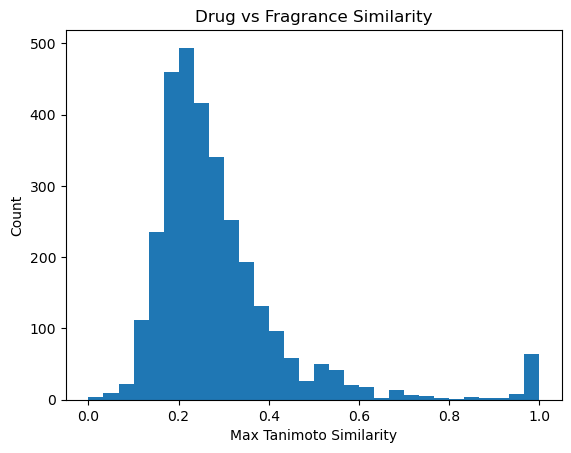

In [40]:
plt.hist(max_sims, bins=30)

plt.xlabel("Max Tanimoto Similarity")
plt.ylabel("Count")
plt.title("Drug vs Fragrance Similarity")

plt.show()

그래프 해석 : 

대부분의  Drug 분자들이 0.15~0.35 근처에 몰려 있음 
특히 최고 봉우리는 약 0.20~0.25 정도. 

반면 0.6 이상은 매우 적음
그리고 0.95~1.0 근처에 작은 봉우리가 있음 

1.0 근처의 의미? 
1.0 = 거의 동일 구조라는 것 

즉 Drug 데이터 안에 Fragrance도 존재하는 분자가 일부 섞여있다는 의미. 

기준?
similarity < 0.30

대부분의 데이터가 0.2 전후에 몰려 있고 
0.3 이상 부터는 Fragrance와 꽤 비슷해지기 때문. 

Morgan fingerprint와 Tanimoto similarity를 이용하여
Fragrance와 Drug 분자의 구조 유사도를 계산하였다.
각 Drug 분자에 대해 Fragrance 분자들과의 최대 유사도를 구하였고,
최대 유사도가 0.30 미만인 분자를 negative dataset으로 선정하였다.

Fragrance와 Drug의 descriptor 분포(MW, TPSA, HBA 등)가
차이를 보였으며, Tanimoto similarity 분포에서도
대부분의 Drug 분자가 0.20~0.30 구간에 위치하였다.
반면 0.30 이상에서는 Fragrance와 유사한 구조가 증가하는
경향을 보였으므로, 구조적으로 충분히 다른 분자를
선별하기 위해 0.30을 기준값으로 사용하였다.

선택한 기준:
Fragrance를 positive,
Drug를 negative로 설정하였다.
Morgan fingerprint와 Tanimoto similarity를 이용하여
구조 유사도를 계산하였다.

이유:
Drug 데이터는 Fragrance와 다른 목적을 가진 화합물 집합이며,
MW, TPSA, HBA 등의 descriptor 분포 차이가 확인되었다.
따라서 score 함수의 구분 능력을 평가하기 위한
negative dataset으로 적절하다고 판단하였다.

**📝 Task 1. 결과 해석 (아래는 예시):**

- 두 분포가 어디서 갈라지는가? (예: 음성 봉우리 ~0.15, 양성 봉우리 ~0.35)
- 어떤 실험을 거쳐서 구조 유사도 기준 값을 설정했는가?

---
# Task 2. Score 함수 설계 (35점)

**문제**: "positive-likeness" 점수를 계산해주는 함수 개발.

**Scoring 방식** 
1. **(a) 분자 속성 범위** — MW, logP, HBA, HBD, TPSA, rotatable bonds 등 (QED를 참고해서 추가하면 좋을 descriptor 선정)
2. **(b) SMARTS 패턴** — 양성에서 자주 나타나는 작용기/하부구조를 포함 or 양성에서 나타나지 않는 구조패턴을 찾아서 제외.

두 점수를 어떻게 결합할지(합/곱/가중합/기하평균/...)도 직접 결정.

In [ ]:
# 셀은 필요한 만큼 추가.

**📝 Score 함수 설계 근거 (아래는 예시):**

- 어떤 SMARTS 패턴을 골랐고 그 이유는?
- 결합 방식과 가중치 선택의 이유는?

---
# Task 3. Score 평가 — Goodness of the score (30점)

**문제**: 본인이 만든 score 함수가 양성과 음성을 얼마나 잘 구분하는가?
- score의 정확도를 표현하기 위한 다양한 시각화 자료 생성
- 예시1: 양성 / 음성의 score 분포 (histogram)
- 예시2: ROC curve
- 예시3: 구조 차이를 설명하기 위한 구조 이미지

In [ ]:
# 시각화

**📝 Score 평가 해석 (아래는 예시):**
1. score가 좋다면, 어떤식의 결과가 예상될까? (예상을 확인할 수 있는 시각화 방법?)
2. 농약에만 있는 구조? 농약에는 없지만 의약품에서만 나타나는 구조? (비교군이 의약품인 경우)

---
# (가산 A) 다른 화학 제품군 score 함수 (+10)

Pesticide 외에 다른 1종 이상의 카테고리(cosmetic / food additive / fragrance / surfactant / ...)에 대해 같은 절차로 score 함수를 만들고 평가 (별도 ipynb로 제출)

PubChem [Classification Browser](https://pubchem.ncbi.nlm.nih.gov/classification) 에서 원하는 카테고리의 CSV 를 다운로드

**시도 하지 않은 경우 아래 부분은 빈칸으로 제출.**

---
# (가산 B) Score 기반 구조 생성 (+10)

본인 score 를 reward 로 사용해 새 구조를 생성. 알고리즘은 자유 (greedy / DP / random walk / 본인 방법). mpi를 사용해서 대규모로 구조를 생성했다면, 생성된 구조의 분포 시각화 (예: histogram, scatter plot 등)을 

**시도하지 않은 경우 아래 부분은 빈칸으로 제출.**

---
# (가산 C) 계산 자원과 계산 시간 (+10)

mpi 혹은 알고리즘 효율화를 통해 계산 시간이 단축되었음을 설명한 경우 주어지는 가산점.
코드에 소요 시간 계산을 위한 코드를 삽입. mpi를 사용해서 시간이 단축되었음을 설명 혹은 문제를 합리적으로 단순화시켜서 계산시간을 단축시켰음을 설명. (계산 시간 비교를 통해 알고리즘의 효율성을 설명해야 함.)